In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 18,
    }
)
plt.rcParams["figure.figsize"] = (8, 5)

In [106]:
df = pd.read_excel("data/Assignment_Dataset_2.xlsx", sheet_name=0)
features = ["DSRI", "GMI", "AQI", "SGI", "DEPI", "SGAI", "ACCR", "LEVI"]

In [107]:
def ratio(col, str1, str2):
    counts = df[col].value_counts()
    male = counts[str1]
    female = counts[str2]
    print(f"{str1}: {str2} = {male}:{female}")
    print(f"Ratio = {male/female:.2f}")


ratio("Manipulater", "Yes", "No")

Yes: No = 39:1200
Ratio = 0.03


In [108]:
# check for nan or missing values
print(df.isnull().sum())
# dataset is filled with some values =1. This is considered correct. Could also
# be a guessed value.

Company ID     0
DSRI           0
GMI            0
AQI            0
SGI            0
DEPI           0
SGAI           0
ACCR           0
LEVI           0
Manipulater    0
dtype: int64


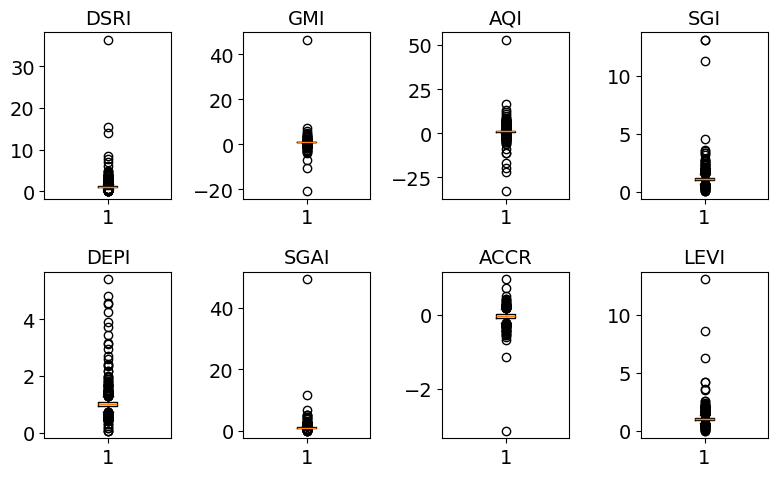

In [109]:
for i, feature in enumerate(features):
    plt.subplot(2, 4, i + 1)
    plt.boxplot(df[feature])
    
    #plt.xlabel(feature)
    plt.title(feature)

plt.tight_layout()
plt.savefig("pictures/boxplots2.pdf", bbox_inches="tight")

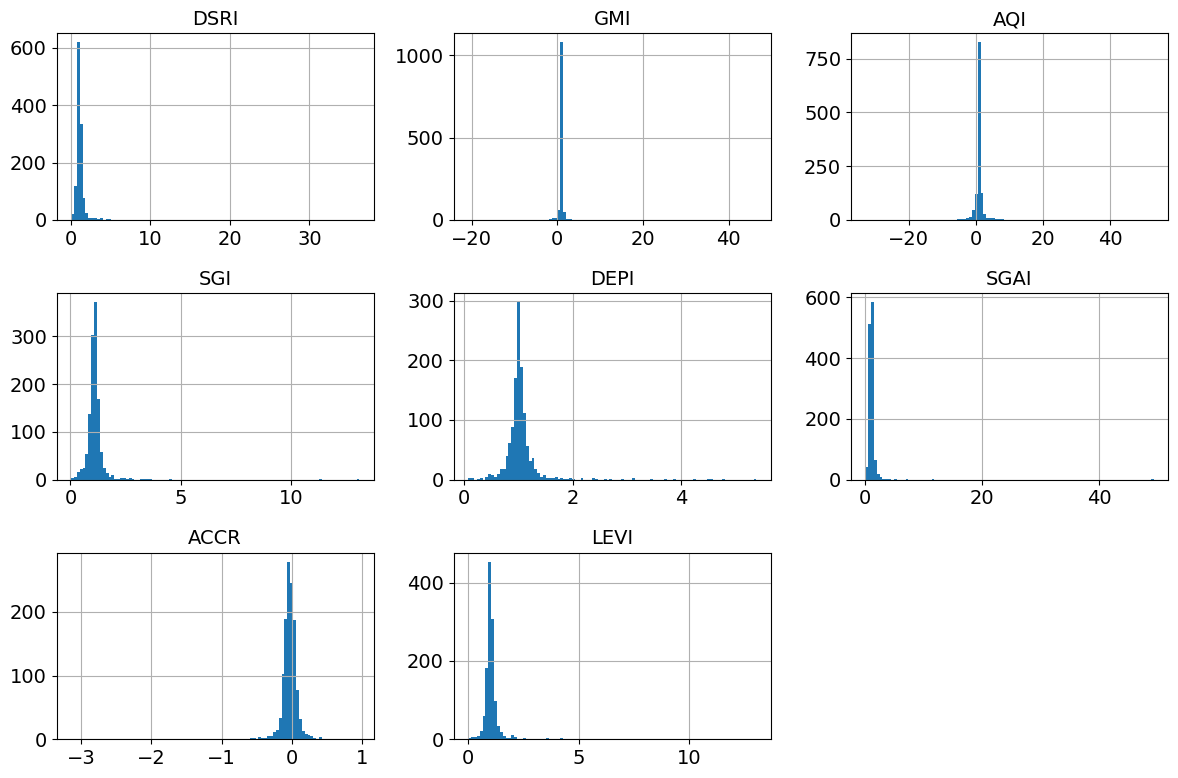

In [110]:
df[features].hist(figsize=(12, 8), bins=100)
plt.tight_layout()
plt.savefig("pictures/histograms2.pdf", bbox_inches="tight")

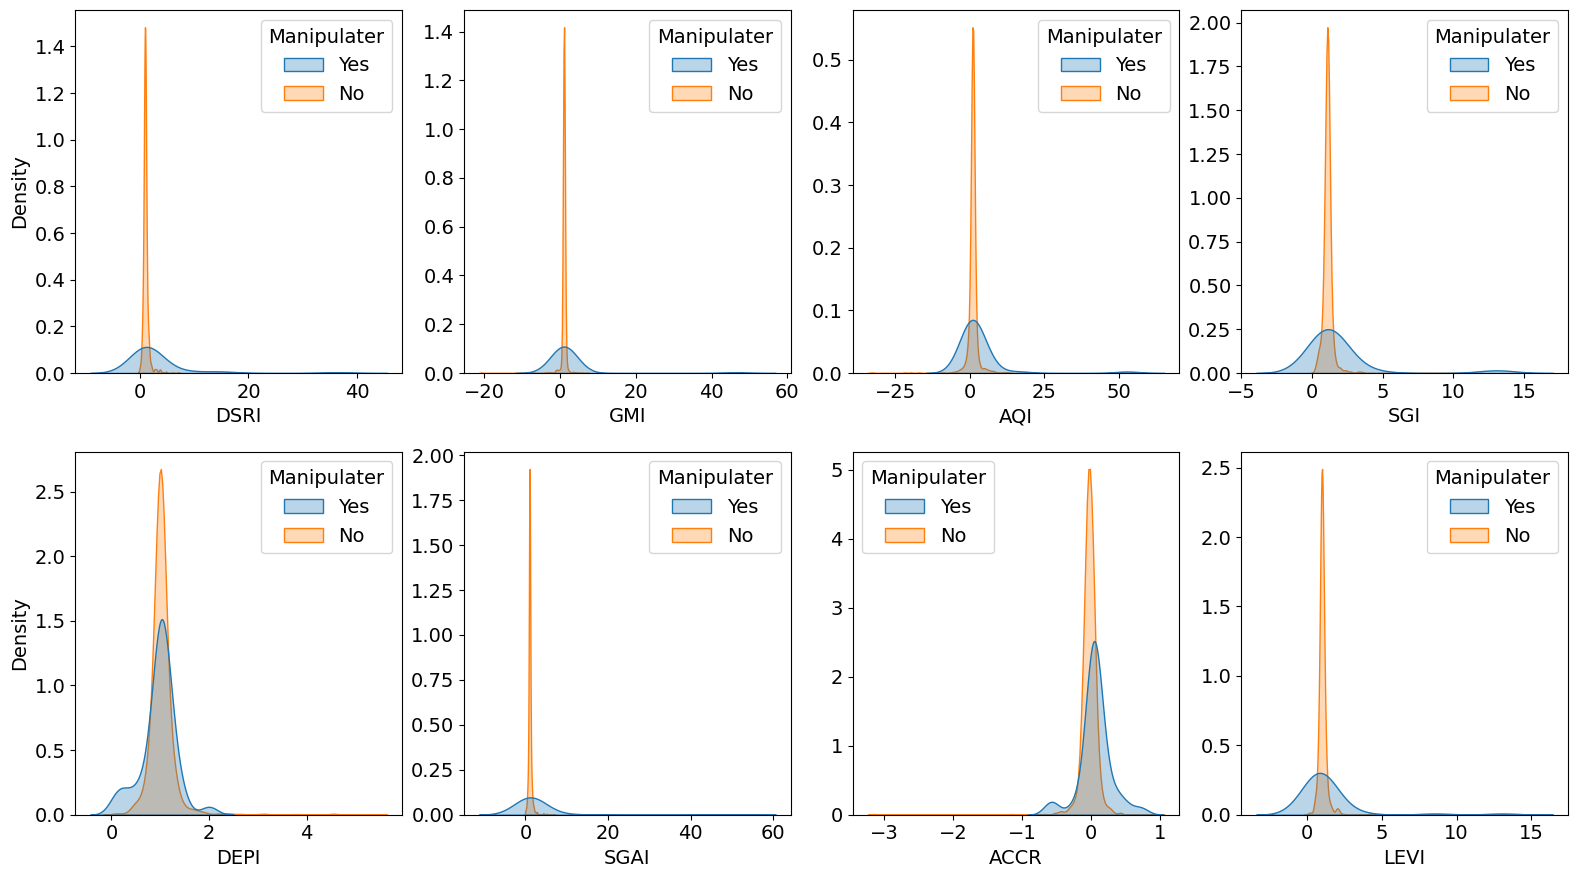

In [111]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

# First five KDE plots
for i, feature in enumerate(features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Manipulater",
        common_norm=False,
        fill=True,
        alpha=0.3,
        ax=axes[i],
    )

    axes[i].set_xlabel(feature)
    # axes[i].set_yscale("log")
axes[0].set_ylabel("Density")
axes[5].set_ylabel("Density")
# alle anderen Y-Labels entfernen
for ax in axes:
    if ax not in [axes[0], axes[4]]:
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig("pictures/kde_2.pdf", bbox_inches="tight")


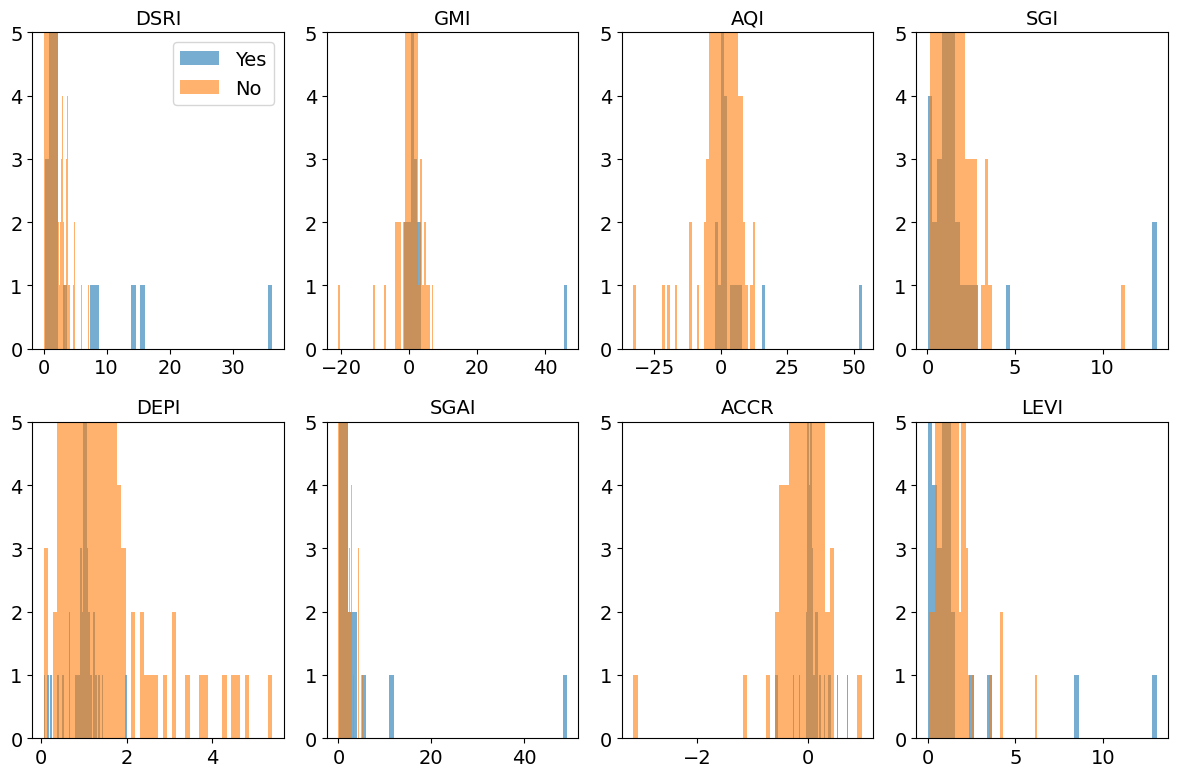

In [112]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):

    ax.hist(
        df[df["Manipulater"]=="Yes"][feature],
        bins=50,
        alpha=0.6,
        label="Yes"
    )

    ax.hist(
        df[df["Manipulater"]=="No"][feature],
        bins=50,
        alpha=0.6,
        label="No"
    )

    ax.set_title(feature)
    ax.set_ylim(0,5)

axes[0,0].legend()
plt.tight_layout()
plt.savefig("pictures/histogram2_zoom.pdf", bbox_inches = "tight")
plt.show()

C:\Users\plays\AppData\Local\Temp\ipykernel_1304\1813039797.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


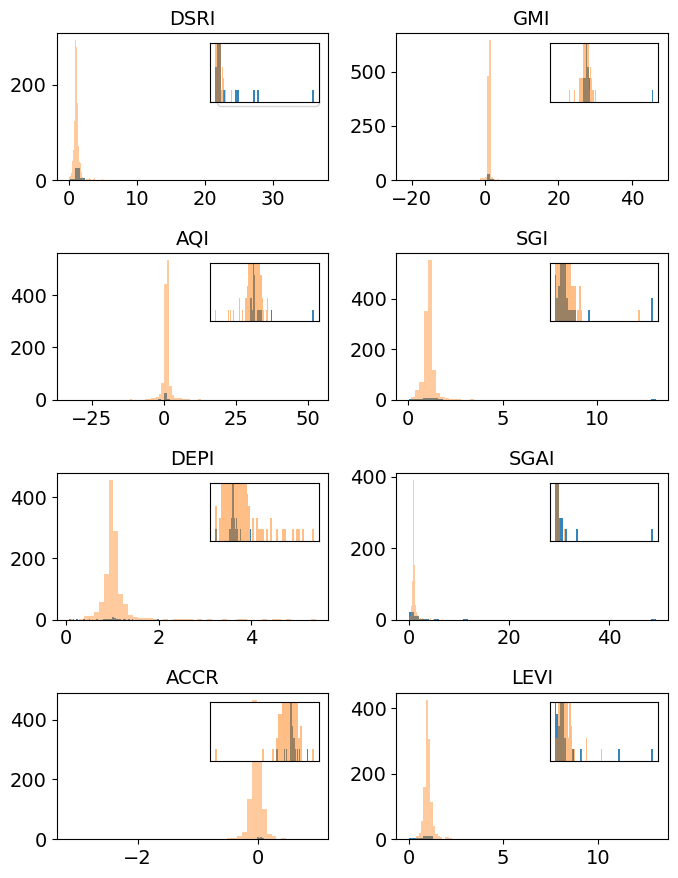

In [113]:
fig, axes = plt.subplots(4, 2, figsize=(7, 9))

for ax, feature in zip(axes.flat, features):

    # Hauptplot
    ax.hist(
        df[df["Manipulater"] == "Yes"][feature],
        bins=50,
        alpha=0.9,
        label="Yes"
    )

    ax.hist(
        df[df["Manipulater"] == "No"][feature],
        bins=50,
        alpha=0.4,
        label="No"
    )

    ax.set_title(feature)

    # ---------- Zoom-Inset ----------
    axins = inset_axes(
        ax,
        width="40%",
        height="40%",
        loc="upper right"
    )

    axins.hist(
        df[df["Manipulater"] == "Yes"][feature],
        bins=50,
        alpha=0.9
    )

    axins.hist(
        df[df["Manipulater"] == "No"][feature],
        bins=50,
        alpha=0.5
    )

    # Zoom auf kleine Häufigkeiten
    axins.set_ylim(0, 5)

    # Achsenbeschriftungen entfernen
    axins.set_xticks([])
    axins.set_yticks([])

axes[0, 0].legend()

plt.tight_layout()
plt.savefig("pictures/detailed_histogram_2.pdf", bbox_inches = "tight")
plt.show()